In [1]:
import os
import sys
import random
import numpy as np
from pathlib import Path

os.chdir(next(p for p in Path.cwd().parents if (p / 'src').exists()))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

env_path = sys.prefix
os.environ['CC'] = f"{env_path}/bin/x86_64-conda-linux-gnu-cc"
os.environ['CXX'] = f"{env_path}/bin/x86_64-conda-linux-gnu-c++"
os.environ['PKG_CONFIG_PATH'] = f"{env_path}/lib/pkgconfig"
os.environ['LD_LIBRARY_PATH'] = f"{env_path}/lib"

import tensorflow as tf

from src.networks.DecoderPINN import PINN
from src.optimization.DecoderTrainer import DecoderTrainer
from src.data.decoder_dataloader import load_parametric_fem_data_lbfgs
from src.data.collocation import generate_parametric_collocation_points
from src.visualization.historyplots import plot_lbfgs_history
from src.visualization.pdeplots import plot_parametric_pinn_solution
from src.physics.physics import get_M_dynamic
from src.hyperparameters import hypers_parametric as h
from src.utils.metrics import compute_test_metrics

tf.keras.backend.clear_session()
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

tf.keras.backend.set_floatx('float64')
number_type = tf.float64

2026-10-03 15:26:54.671013: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1791034014.689763   79410 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1791034014.697149   79410 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1791034014.704895   79410 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791034014.704912   79410 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791034014.704913   79410 computation_placer.cc:177] computation placer alr

In [2]:
output_dir = 'models/pipeline_evolution/03_parametric_pinn'
results_dir = 'results/pipeline_evolution/03_parametric_pinn'
data_dir = 'data/parametric/400x400'

train_path = os.path.join(data_dir, 'train.npz')
val_path = os.path.join(data_dir, 'val.npz')
test_path = os.path.join(data_dir, 'test.npz')
scale_load_path = os.path.join(data_dir, 'u_scale.npy')

os.makedirs(output_dir, exist_ok=True)

# Load parametric FEM data
(x_train_pinn, u_train_pinn), (x_val_pinn, u_val_pinn), (x_test_pinn, u_test_pinn), U_SCALE = load_parametric_fem_data_lbfgs(
        train_path=train_path,
    val_path=val_path,
    test_path=test_path,
    scale_load_path=scale_load_path,
    n_lbfgs_data=25000,
    dtype=number_type
)

Loading Parametric FEM data for L-BFGS from:
data/parametric/400x400/train.npz
data/parametric/400x400/val.npz
data/parametric/400x400/test.npz
Applied pre-computed noise.
U_SCALE (loaded): 0.07277622818946838


I0000 00:00:1791034017.571706   79410 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0


Shape x_train: (25000, 4)
Shape x_val:   (100980, 4)
Shape x_test:  (103020, 4)


In [3]:
# Model creation
model = PINN(h.N_NEURONS_DECODER, U_SCALE)
model(tf.zeros((1, 4), dtype=number_type)) 

# Transfer Learning
pretrained_weights = os.path.join(output_dir, 'decoder_adam.weights.h5')
model.load_weights(pretrained_weights)
print(f"Transfer Learning from Adam weights: {pretrained_weights}")

Transfer Learning from Adam weights: models/pipeline_evolution/03_parametric_pinn/decoder_adam.weights.h5


In [4]:
N_interior = h.N_INTERIOR_LBFGS
N_boundary = h.N_BOUNDARY_LBFGS  
N_activation = h.N_ACTIVATION_LBFGS

x_int, x_boundary, n_boundary, num_neumann = generate_parametric_collocation_points(N_interior,
                                                                                    N_boundary,
                                                                                    N_activation,
                                                                                    r_a=1.0/400,
                                                                                    dtype=number_type)

In [5]:
# LOSS PARAMETERS
lambdas = {
    'pde': h.LAMBDA_PDE_LBFGS,
    'neu': h.LAMBDA_NEU_LBFGS,
    'dir': h.LAMBDA_DIR_LBFGS,
    'data': h.LAMBDA_DATA_LBFGS
}

trainer = DecoderTrainer(model=model, output_dir=output_dir, result_dir=results_dir)

trainer.train_lbfgs(x_int=x_int,
                    x_boundary=x_boundary,
                    n_boundary=n_boundary,
                    num_neumann=num_neumann,
                    x_data=x_train_pinn,
                    u_data=u_train_pinn,
                    x_val=x_val_pinn,
                    u_val=u_val_pinn,
                    physics_fn=get_M_dynamic,
                    lambdas=lambdas,
                    max_iterations=h.MAX_LBFGS_ITERATIONS,
                    num_correction_pairs=h.NUM_CORRECTION_PAIRS_LBFGS,
                    tolerance=h.TOLERANCE_LBFGS,
                    x_tolerance=h.X_TOLERANCE_LBFGS,
                    f_relative_tolerance=h.F_RELATIVE_TOLERANCE_LBFGS,
                    number_type=number_type)


Starting L-BFGS optimization...


I0000 00:00:1791034019.285348   79410 service.cc:152] XLA service 0x580dc781ea90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791034019.285421   79410 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 5080, Compute Capability 12.0
I0000 00:00:1791034019.652327   79410 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1791034021.584646   79410 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Call to loss_grad: 0 | Loss: 0.0046322331893807493 | PDE: 0.0002895881067561371 | Dir: 1.531868931192647e-06 | Neu: 8.753745011371148e-05 | Data: 0.00041885828150042104 | Validation: 0.00042179958430350645
Call to loss_grad: 500 | Loss: 0.0042021721290387047 | PDE: 0.00012386437462039827 | Dir: 2.7434604582605842e-07 | Neu: 0.00010724460236997912 | Data: 0.0004049800703812001 | Validation: 0.00041151767942458845
Call to loss_grad: 1000 | Loss: 0.0041161631789267674 | PDE: 0.00010296048296545145 | Dir: 2.0164916302938102e-07 | Neu: 0.00011120890711979196 | Data: 0.00039919256905871794 | Validation: 0.0004070999549950634
Call to loss_grad: 1500 | Loss: 0.0040582383868403935 | PDE: 8.5886450812271042e-05 | Dir: 1.4601906025758104e-07 | Neu: 0.00011639105259863656 | Data: 0.00039565861194763781 | Validation: 0.00040365159016528853
Call to loss_grad: 2000 | Loss: 0.0040169487093438217 | PDE: 7.1896963255211263e-05 | Dir: 1.1089724394849383e-07 | Neu: 0.00011833646534797623 | Data: 0.0003932

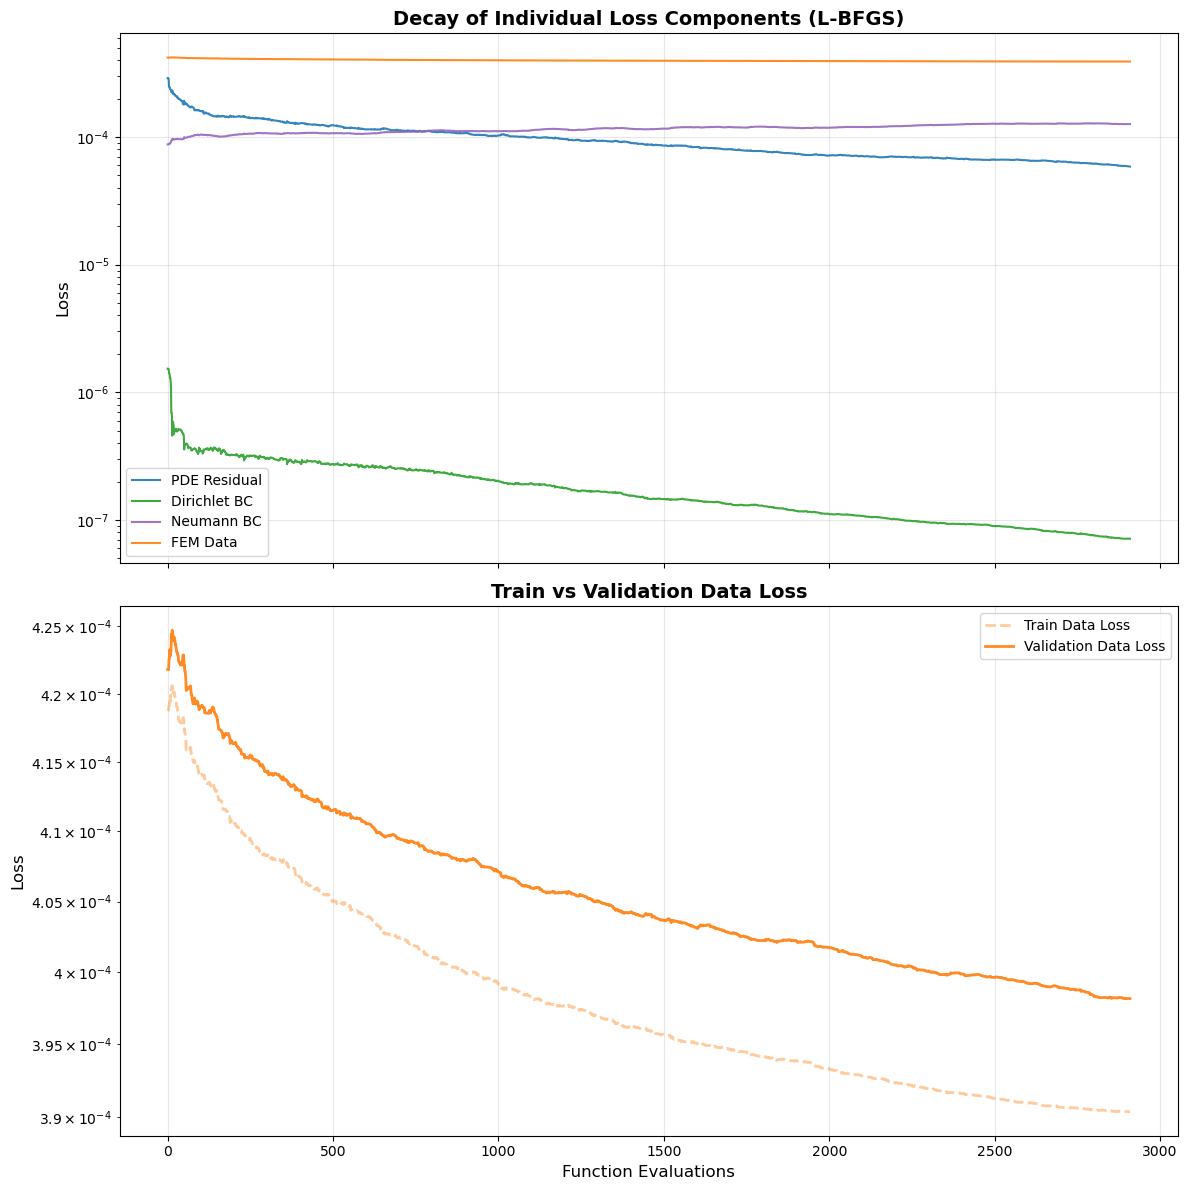

In [6]:
history_lbfgs_path = os.path.join(output_dir, 'decoder_lbfgs.loss.npz')
np.savez(history_lbfgs_path, **trainer.history_lbfgs)
history_lbfgs_clean = plot_lbfgs_history(trainer.history_lbfgs)

Generating map for scar at: (0.5, 0.5)


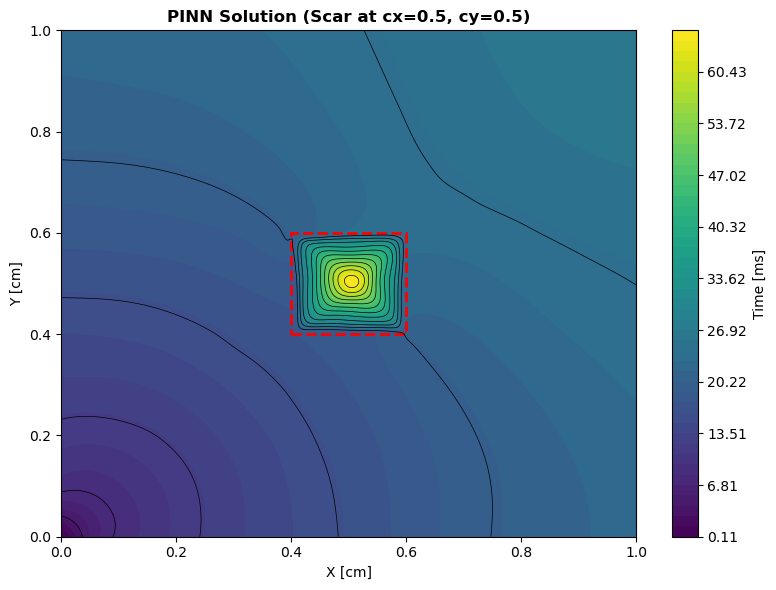

In [7]:
cx_test = 0.5
cy_test = 0.5
print(f"Generating map for scar at: ({cx_test}, {cy_test})")

N_plot = 400 
x_val = np.linspace(0, 1, N_plot)
y_val = np.linspace(0, 1, N_plot)
X, Y = np.meshgrid(x_val, y_val)

X_flat_1D = X.flatten()
Y_flat_1D = Y.flatten()
cx_array = np.full_like(X_flat_1D, cx_test)
cy_array = np.full_like(Y_flat_1D, cy_test)

X_flat_4D = np.column_stack((X_flat_1D, Y_flat_1D, cx_array, cy_array))


u_pred_flat = model(tf.convert_to_tensor(X_flat_4D, dtype=number_type)).numpy() * U_SCALE
U_PINN = u_pred_flat.reshape(N_plot, N_plot) * 1000.0


plot_parametric_pinn_solution(
    X_fem=X, 
    Y_fem=Y, 
    U_pinn2D=U_PINN, 
    cx_test=cx_test, 
    cy_test=cy_test
)

In [8]:
data_test = np.load(test_path)
coords_test = data_test['coords']   
values_test = data_test['values_clean']

l2_error, mae_error = compute_test_metrics(
    model=model, 
    coords_test=coords_test, 
    values_test=values_test, 
    U_SCALE=U_SCALE, 
    dtype=number_type
)

L2 Relative Error vs FEM   : 1.2261%
Mean Absolute Error (Phys) : 0.1462 ms
